# Lightweight supervised models for strut condition

This notebook compares three small classifiers for **normal vs bad struts** and includes an optional **normal vs intentionally bad vs unintentionally bad** experiment.

Important: the current high/critical labels are CT screening labels, not human-verified ground truth. Because they were derived from related CT features, the binary experiment measures how well a compact model reproduces the screening rule—not final real-world defect accuracy.

In [7]:
# Run once if the selected notebook kernel does not have these packages.
%pip install -q scikit-learn pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, average_precision_score, balanced_accuracy_score,
    classification_report, precision_recall_curve, precision_score,
    recall_score, roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

pd.set_option('display.max_columns', 100)
RANDOM_STATE = 42

In [9]:
base = Path.cwd()
data_dir = base / 'strut_feature_dataset' if (base / 'strut_feature_dataset').exists() else base
df = pd.read_csv(data_dir / 'strut_features_combined.csv')

# Optional future file produced by STL-to-nominal-strut matching.
# Required columns: specimen_id, strut_id, intentional_defect
intentional_path = data_dir / 'intentional_strut_labels.csv'
if intentional_path.exists():
    intentional = pd.read_csv(intentional_path)
    df = df.merge(
        intentional[['specimen_id', 'strut_id', 'intentional_defect']],
        on=['specimen_id', 'strut_id'], how='left',
    )

df['bad_strut'] = df['ct_severity_layer'].isin(['high', 'critical']).astype(int)
print(f"Rows: {len(df):,}; bad weak labels: {df['bad_strut'].sum():,} ({df['bad_strut'].mean():.3%})")
df['ct_severity_layer'].value_counts()

Rows: 18,468; bad weak labels: 92 (0.498%)


ct_severity_layer
supported    17914
watch          277
moderate       185
high            74
critical        18
Name: count, dtype: int64

## Features and leakage control

`ct_defect_score`, rank, screening label, and severity are excluded because they directly define the target. Geometry features test where failures tend to occur; primitive CT/profile features describe observed material support. Even after these exclusions, this remains weak supervision because the target originated from CT measurements.

In [10]:
numeric_features = [
    'ct_support_fraction', 'ct_longest_gap_fraction',
    'ct_profile_min_to_mean', 'ct_continuity_score',
    'ct_relative_local_intensity',
    'length_mm', 'angle_to_build_z_deg', 'azimuth_xy_deg',
    'minimum_endpoint_degree', 'mean_endpoint_degree',
    'neighboring_strut_count', 'endpoint_on_boundary_count',
    'minimum_midpoint_boundary_distance_mm', 'near_boundary_one_cell',
    'slenderness_length_over_diameter',
]
categorical_features = ['orientation_class']
numeric_features = [c for c in numeric_features if c in df.columns]
categorical_features = [c for c in categorical_features if c in df.columns]
feature_columns = numeric_features + categorical_features

preprocess = ColumnTransformer([
    ('numeric', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', RobustScaler()),
    ]), numeric_features),
    ('category', OneHotEncoder(handle_unknown='ignore'), categorical_features),
])

print(f'Using {len(feature_columns)} input features')

Using 16 input features


In [11]:
# Keep entire unit cells together to reduce spatial leakage between neighboring struts.
# Prefix with specimen_id so future multi-specimen tables remain properly grouped.
groups = df['specimen_id'].astype(str) + ':' + df['unit_cell_id'].astype(str)
splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(df[feature_columns], df['bad_strut'], groups))

X_train, X_test = df.iloc[train_idx][feature_columns], df.iloc[test_idx][feature_columns]
y_train, y_test = df.iloc[train_idx]['bad_strut'], df.iloc[test_idx]['bad_strut']

print(f'Train: {len(train_idx):,} rows, {y_train.sum()} bad')
print(f'Test:  {len(test_idx):,} rows, {y_test.sum()} bad')

Train: 13,836 rows, 72 bad
Test:  4,632 rows, 20 bad


In [12]:
estimators = {
    'Logistic regression': LogisticRegression(
        class_weight='balanced', C=0.5, max_iter=2000, random_state=RANDOM_STATE
    ),
    'Small decision tree': DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=20, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Light random forest': RandomForestClassifier(
        n_estimators=150, max_depth=9, min_samples_leaf=5,
        max_features='sqrt', class_weight='balanced_subsample',
        n_jobs=-1, random_state=RANDOM_STATE,
    ),
}

models = {}
rows = []
probabilities = {}

for name, estimator in estimators.items():
    model = Pipeline([('preprocess', preprocess), ('classifier', estimator)])
    model.fit(X_train, y_train)
    probability = model.predict_proba(X_test)[:, 1]
    prediction = (probability >= 0.5).astype(int)
    models[name] = model
    probabilities[name] = probability
    rows.append({
        'model': name,
        'average_precision': average_precision_score(y_test, probability),
        'roc_auc': roc_auc_score(y_test, probability),
        'balanced_accuracy_at_0.5': balanced_accuracy_score(y_test, prediction),
        'precision_at_0.5': precision_score(y_test, prediction, zero_division=0),
        'recall_at_0.5': recall_score(y_test, prediction, zero_division=0),
        'flagged_at_0.5': int(prediction.sum()),
    })

results = pd.DataFrame(rows).sort_values('average_precision', ascending=False)
metric_columns = [
    'average_precision', 'roc_auc', 'balanced_accuracy_at_0.5',
    'precision_at_0.5', 'recall_at_0.5',
]
display(results.assign(**{column: results[column].round(3) for column in metric_columns}))

,model,average_precision,roc_auc,balanced_accuracy_at_0.5,precision_at_0.5,recall_at_0.5,flagged_at_0.5
0,Logistic regression,0.945,1.000,0.995,0.317,1.00,63
2,Light random forest,0.865,0.999,0.973,0.576,0.95,33
1,Small decision tree,0.844,0.974,0.973,0.452,0.95,42


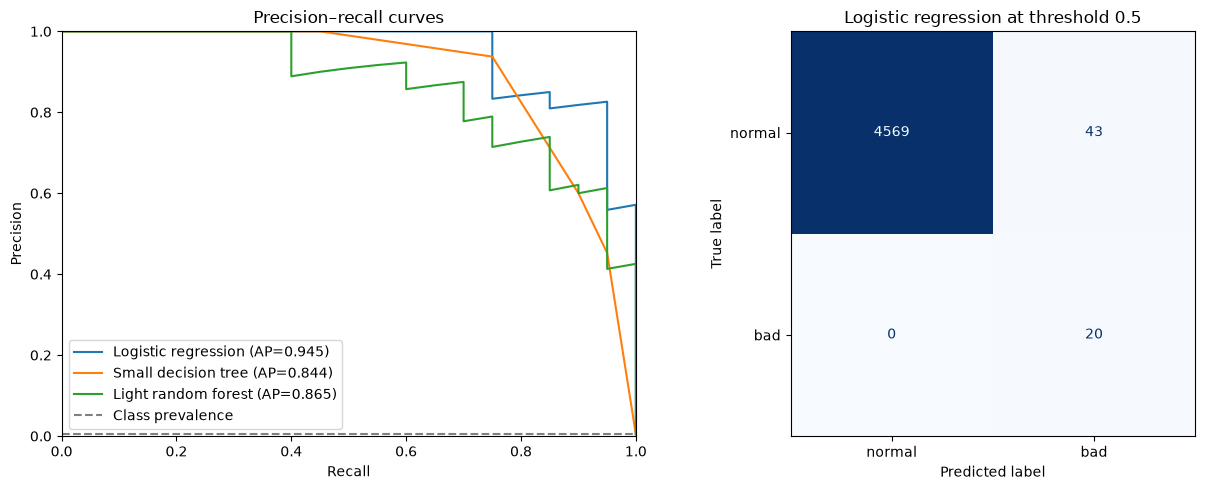

              precision    recall  f1-score   support

      normal       1.00      0.99      1.00      4612
         bad       0.32      1.00      0.48        20

    accuracy                           0.99      4632
   macro avg       0.66      1.00      0.74      4632
weighted avg       1.00      0.99      0.99      4632



In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, probability in probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, probability)
    ap = average_precision_score(y_test, probability)
    axes[0].plot(recall, precision, label=f'{name} (AP={ap:.3f})')
axes[0].axhline(y_test.mean(), color='gray', linestyle='--', label='Class prevalence')
axes[0].set(xlabel='Recall', ylabel='Precision', title='Precision–recall curves', xlim=(0, 1), ylim=(0, 1))
axes[0].legend()

best_name = results.iloc[0]['model']
best_probability = probabilities[best_name]
best_prediction = (best_probability >= 0.5).astype(int)
ConfusionMatrixDisplay.from_predictions(
    y_test, best_prediction, display_labels=['normal', 'bad'], cmap='Blues', ax=axes[1], colorbar=False
)
axes[1].set_title(f'{best_name} at threshold 0.5')
fig.tight_layout()
plt.show()

print(classification_report(y_test, best_prediction, target_names=['normal', 'bad'], zero_division=0))

In [14]:
# For screening, choose a threshold that targets high recall instead of assuming 0.5.
precision, recall, thresholds = precision_recall_curve(y_test, best_probability)
eligible = np.where(recall[:-1] >= 0.90)[0]
if len(eligible):
    chosen_idx = eligible[np.argmax(precision[:-1][eligible])]
    screening_threshold = thresholds[chosen_idx]
else:
    screening_threshold = 0.5

screening_prediction = (best_probability >= screening_threshold).astype(int)
print(f'Best model: {best_name}')
print(f'90%-recall screening threshold: {screening_threshold:.4f}')
print(f'Precision: {precision_score(y_test, screening_prediction, zero_division=0):.3f}')
print(f'Recall:    {recall_score(y_test, screening_prediction, zero_division=0):.3f}')
print(f'Flagged:   {screening_prediction.sum()} of {len(screening_prediction)} test struts')

Best model: Logistic regression
90%-recall screening threshold: 0.9631
Precision: 0.826
Recall:    0.950
Flagged:   23 of 4632 test struts


,feature,importance
4,ct_relative_local_intensity,0.929744
2,ct_profile_min_to_mean,0.276186
1,ct_longest_gap_fraction,0.129148
7,azimuth_xy_deg,0.041429
8,minimum_endpoint_degree,0.036525
3,ct_continuity_score,0.023674
0,ct_support_fraction,0.004323
9,mean_endpoint_degree,0.003647
10,neighboring_strut_count,0.003647
11,endpoint_on_boundary_count,0.001825


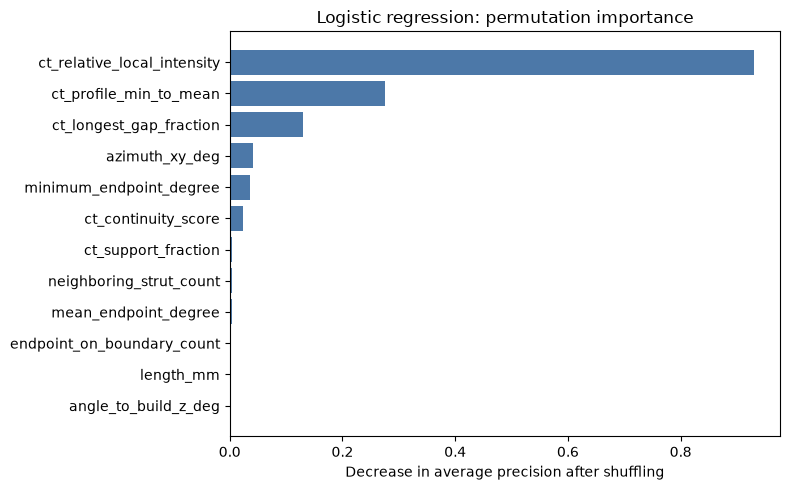

In [15]:
# Permutation importance is calculated on original named columns and works for every pipeline.
importance = permutation_importance(
    models[best_name], X_test, y_test,
    scoring='average_precision', n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1,
)
importance_table = (
    pd.DataFrame({'feature': feature_columns, 'importance': importance.importances_mean})
      .sort_values('importance', ascending=False)
)
display(importance_table)

top = importance_table.head(12).sort_values('importance')
plt.figure(figsize=(8, 5))
plt.barh(top['feature'], top['importance'], color='#4c78a8')
plt.xlabel('Decrease in average precision after shuffling')
plt.title(f'{best_name}: permutation importance')
plt.tight_layout()
plt.show()

## Optional three-class model

The three desired classes require a trustworthy `intentional_defect` flag produced by comparing each design STL with the complete nominal strut graph. Specimen-level names such as `0.5-1` only tell us the designed percentage; they do not identify which individual struts Jenny removed. The next cell runs only when `intentional_strut_labels.csv` exists.

In [16]:
if 'intentional_defect' not in df.columns or df['intentional_defect'].isna().all():
    print('Three-class model skipped: intentional_strut_labels.csv is not available yet.')
else:
    usable = df['intentional_defect'].notna().copy()
    three_class = np.select(
        [
            df['intentional_defect'].fillna(False).astype(bool),
            df['bad_strut'].eq(1),
        ],
        ['intentionally_bad', 'unintentionally_bad'],
        default='normal',
    )
    df['condition_class'] = three_class
    print(df.loc[usable, 'condition_class'].value_counts())

    train_mask = usable.iloc[train_idx].to_numpy()
    test_mask = usable.iloc[test_idx].to_numpy()
    X3_train = X_train.loc[train_mask]
    X3_test = X_test.loc[test_mask]
    y3_train = df.iloc[train_idx].loc[train_mask, 'condition_class']
    y3_test = df.iloc[test_idx].loc[test_mask, 'condition_class']

    model3 = Pipeline([
        ('preprocess', preprocess),
        ('classifier', LogisticRegression(
            class_weight='balanced', C=0.5, max_iter=3000, random_state=RANDOM_STATE
        )),
    ])
    model3.fit(X3_train, y3_train)
    prediction3 = model3.predict(X3_test)
    print(classification_report(y3_test, prediction3, zero_division=0))
    ConfusionMatrixDisplay.from_predictions(y3_test, prediction3, cmap='Blues', xticks_rotation=25)
    plt.title('Three-class logistic regression')
    plt.tight_layout()
    plt.show()

Three-class model skipped: intentional_strut_labels.csv is not available yet.


In [17]:
# Refit the selected lightweight model on all weak labels and save per-strut probabilities.
final_model = models[best_name]
final_model.fit(df[feature_columns], df['bad_strut'])
df['supervised_bad_probability'] = final_model.predict_proba(df[feature_columns])[:, 1]
df['supervised_bad_prediction'] = df['supervised_bad_probability'] >= screening_threshold

output_path = data_dir / 'spatial_sequence_anomaly' / 'datasets' / 'supervised_strut_predictions.csv'
output_path.parent.mkdir(parents=True, exist_ok=True)
df[['specimen_id', 'strut_id', 'bad_strut', 'supervised_bad_probability',
    'supervised_bad_prediction']].to_csv(output_path, index=False)
print(f'Saved predictions to: {output_path.resolve()}')

Saved predictions to: C:\Users\oconn\DSC2026\llnl_data_science_challenge_2026\strut_feature_dataset\spatial_sequence_anomaly\datasets\supervised_strut_predictions.csv
